# Name:Jakiel
# Date: 11-20-25 
## Using Medical Costs Dataset (Predict insurance charges based on age, BMI, smoking status)



# Section 1. Import and Inspect the Data



In [52]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split


In [53]:
# 1.1 Load the dataset and display the first 10 rows.
insco = pd.read_csv('insurance.csv')
insco.head(10)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [54]:
# 1.2 Check for missing values and display summary statistics.
print(insco.isna().sum())

print(insco.info())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


Reflection 1: What do you notice about the dataset? Are there any data issues?



# Section 2. Data Exploration and Preparation



In [55]:
#convert categorical features to numeric
insco['smoker'] = insco['smoker'].map({'yes': 1, 'no': 0})
insco['sex'] = insco['sex'].map({'male':1,'female':0})


In [56]:
#display correlation  for feature selection
insco.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


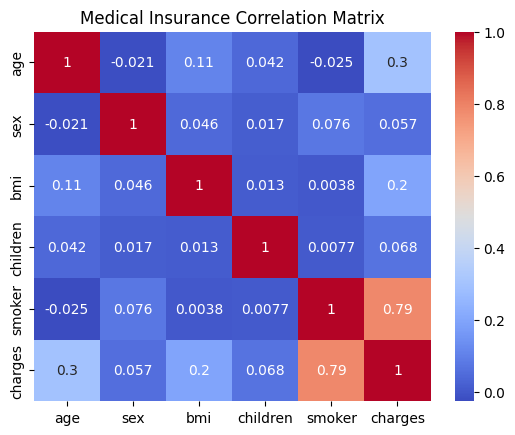

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
Name: charges, dtype: float64

In [57]:
# plot correlation matrix 
sns.heatmap(insco.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Medical Insurance Correlation Matrix")
plt.show()

insco.corr(numeric_only=True)['charges'].sort_values(ascending=False)


Reflection 2: What patterns or anomalies do you see? Do any features stand out? What preprocessing steps were necessary to clean and improve the data? Did you create or modify any features to improve performance?



# Section 3. Feature Selection and Justification



3.1 Choose features and target

I will use the features smoker ,bmi,age, children to predict the price the insurnace company charges the person.

In [58]:
#3.2 Define X and y
X = insco[['smoker', 'bmi', 'age', 'children']]
Y = insco['charges']

Reflection 3: Why did you choose these features? How might they impact predictions or accuracy?



# Section 4. Train a Model (Linear Regression)



In [59]:
#4.1 Split the data into training and test sets using train_test_split (or StratifiedShuffleSplit if class imbalance is an issue).
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=123)
print("Train size", len(X_train))
print("Test size", len(X_test))

Train size 1070
Test size 268


In [60]:
#4.2 Train model using Scikit-Learn model.fit() method
lr_model = LinearRegression().fit(X_train, Y_train)

#Predict on test and train sets
Y_pred_train = lr_model.predict(X_train)
Y_pred_test = lr_model.predict(X_test)


In [61]:
#4.3 Evalulate performance R2,MAE,RMSE
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print("Training R2:",r2_score(Y_train,Y_pred_train))
print("R2:", r2_score(Y_test, Y_pred_test))
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(Y_test, Y_pred_test))


Training R2: 0.7363720991582904
R2: 0.799036524815733
RMSE: 5543.141792764445
MAE: 4074.8228873944904


Reflection 4: How well did the model perform? Any surprises in the results?



# Section 5. Improve the Model or Try Alternates (Implement Pipelines)



In [62]:
#5.1 Implement Pipeline 1: Imputer → StandardScaler → Linear Regression.
#5.2 Implement Pipeline 2: Imputer → Polynomial Features (degree=3) → StandardScaler → Linear Regression.
#5.3 Compare performance of all models across the same performance metrics